# Leukemia Gene Expression Analysis
### Based on the Golub et al. (1999) dataset

This project analyzes gene expression data from 72 leukemia patients (47 ALL, 25 AML) 
using Python (pandas, matplotlib). 

The analysis includes:
- Distribution of cancer types across patient samples
- Gene expression levels across patient samples
- Identification of the top 10 genes with the largest expression differences between ALL and AML

The goal is to explore which genes could serve as potential biomarkers for distinguishing 
between Acute Lymphoblastic Leukemia (ALL) and Acute Myeloid Leukemia (AML).

In [18]:
df2 = pd.read_csv('archive/data_set_ALL_AML_train.csv')
print(df2.shape)
df2.head()

(7129, 78)


,Gene Description,Gene Accession Number,1,call,2,call.1,3,call.2,4,call.3,...,29,call.33,30,call.34,31,call.35,32,call.36,33,call.37
0,AFFX-BioB-5_at (endogenous control),AFFX-BioB-5_at,-214,A,-139,A,-76,A,-135,A,...,15,A,-318,A,-32,A,-124,A,-135,A
1,AFFX-BioB-M_at (endogenous control),AFFX-BioB-M_at,-153,A,-73,A,-49,A,-114,A,...,-114,A,-192,A,-49,A,-79,A,-186,A
2,AFFX-BioB-3_at (endogenous control),AFFX-BioB-3_at,-58,A,-1,A,-307,A,265,A,...,2,A,-95,A,49,A,-37,A,-70,A
3,AFFX-BioC-5_at (endogenous control),AFFX-BioC-5_at,88,A,283,A,309,A,12,A,...,193,A,312,A,230,P,330,A,337,A
4,AFFX-BioC-3_at (endogenous control),AFFX-BioC-3_at,-295,A,-264,A,-376,A,-419,A,...,-51,A,-139,A,-367,A,-188,A,-407,A


In [19]:
# Check how many ALL vs AML patients we have
print(df['cancer'].value_counts())

cancer
ALL    47
AML    25
Name: count, dtype: int64


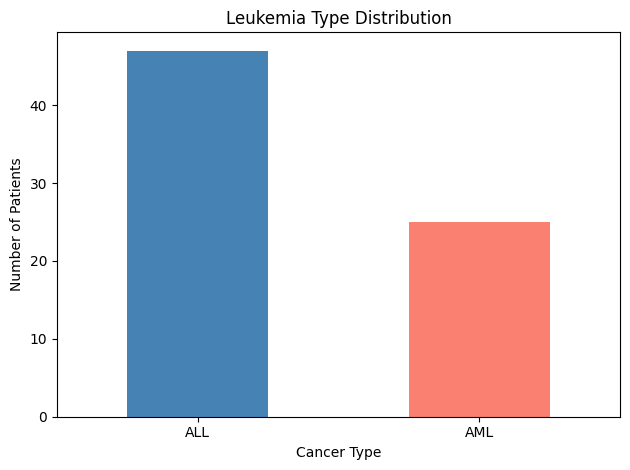

In [20]:
# Visualize the class distribution
df['cancer'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Leukemia Type Distribution')
plt.xlabel('Cancer Type')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

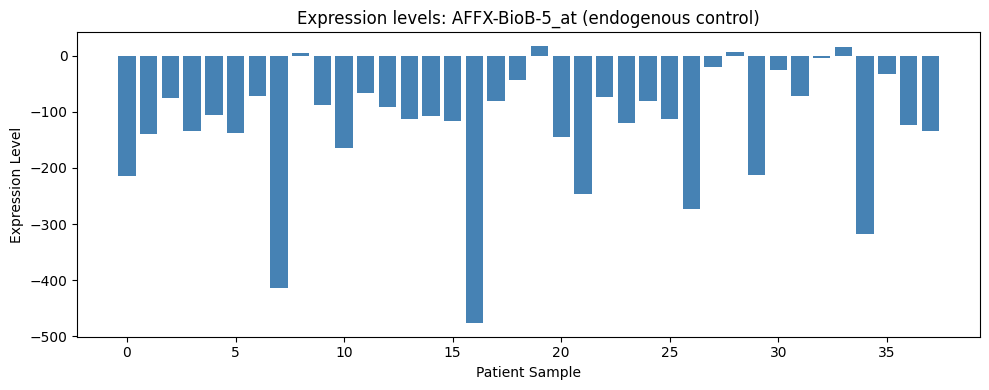

In [21]:
# Look at expression levels for the first gene across both cancer types
gene = df2.iloc[0]['Gene Description']
expression = pd.to_numeric(df2.iloc[0, 2:], errors='coerce').dropna().values

plt.figure(figsize=(10,4))
plt.bar(range(len(expression)), expression, color='steelblue')
plt.title(f'Expression levels: {gene}')
plt.xlabel('Patient Sample')
plt.ylabel('Expression Level')
plt.tight_layout()
plt.show()

In [22]:
print(df2.columns[:10].tolist())
print(df['patient'][:5].tolist())

['Gene Description', 'Gene Accession Number', '1', 'call', '2', 'call.1', '3', 'call.2', '4', 'call.3']
[1, 2, 3, 4, 5]


In [23]:
# Find which patients are actually in df2
available_cols = set(expr_cols)

all_samples = [str(i) for i in df[df['cancer']=='ALL']['patient'].values if str(i) in available_cols]
aml_samples = [str(i) for i in df[df['cancer']=='AML']['patient'].values if str(i) in available_cols]

print("ALL samples found:", len(all_samples))
print("AML samples found:", len(aml_samples))

ALL samples found: 27
AML samples found: 11


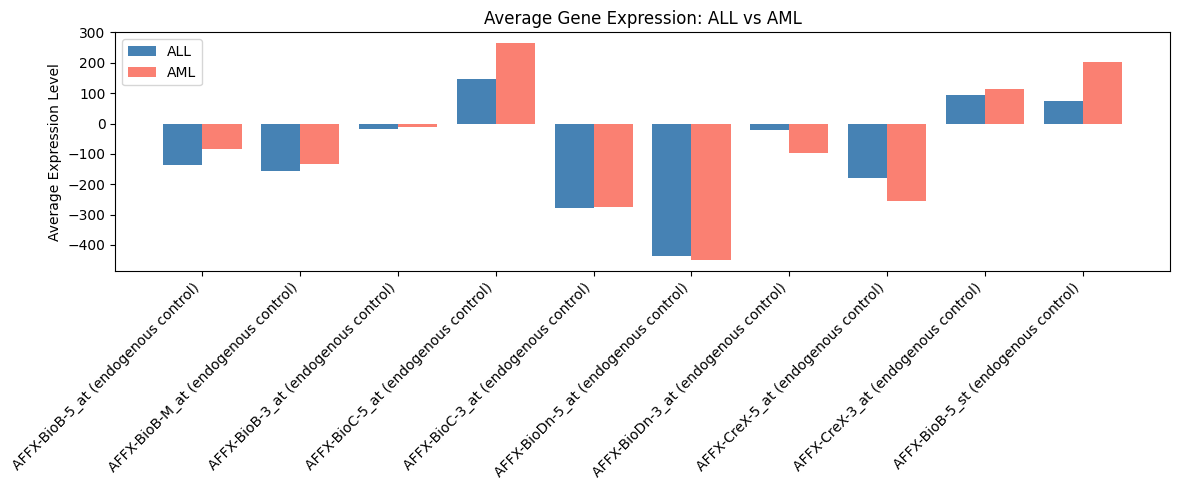

In [24]:
all_means = numeric_df[all_samples].mean(axis=1)
aml_means = numeric_df[aml_samples].mean(axis=1)

x = range(10)
plt.figure(figsize=(12,5))
plt.bar([i-0.2 for i in x], all_means, width=0.4, label='ALL', color='steelblue')
plt.bar([i+0.2 for i in x], aml_means, width=0.4, label='AML', color='salmon')
plt.xticks(list(x), numeric_df.index, rotation=45, ha='right')
plt.title('Average Gene Expression: ALL vs AML')
plt.ylabel('Average Expression Level')
plt.legend()
plt.tight_layout()
plt.show()

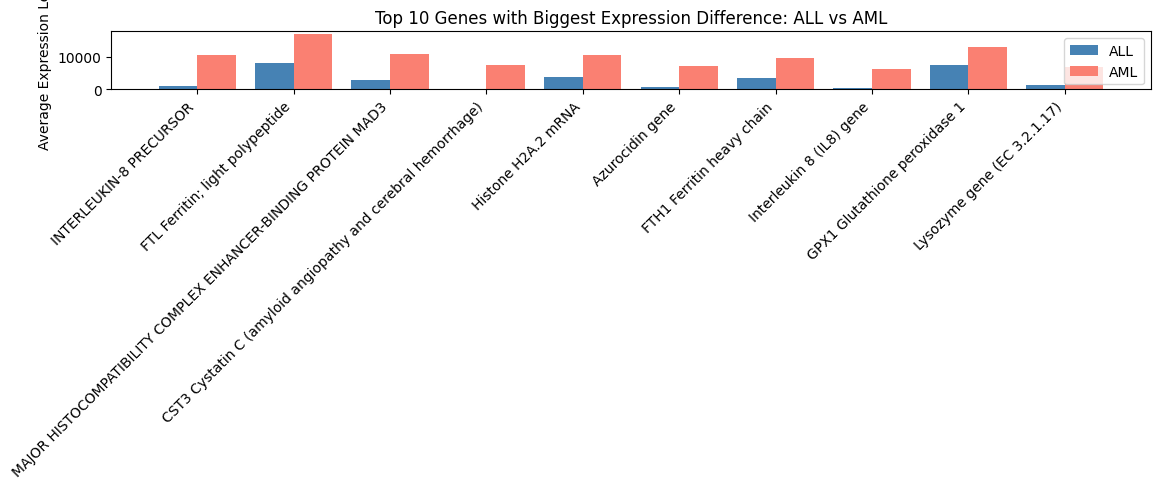

In [ ]:
all_means_clean = all_means_full[~all_means_full.index.duplicated()]
aml_means_clean = aml_means_full[~aml_means_full.index.duplicated()]
diff_clean = (all_means_clean - aml_means_clean).abs().sort_values(ascending=False)
top10_genes = diff_clean.head(10).index

plt.figure(figsize=(12,5))
plt.bar([i-0.2 for i in range(10)], all_means_clean[top10_genes], width=0.4, label='ALL', color='steelblue')
plt.bar([i+0.2 for i in range(10)], aml_means_clean[top10_genes], width=0.4, label='AML', color='salmon')
plt.xticks(range(10), top10_genes, rotation=45, ha='right')
plt.title('Top 10 Genes with Biggest Expression Difference: ALL vs AML')
plt.ylabel('Average Expression Level')
plt.legend()
plt.tight_layout()
plt.show()